In [35]:
import torch
import torch.utils.data
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
import time

$U^{''}+U = -\pi^2 \sin(\pi x)$

U(0) = 0

U(1) = 0

In [91]:
class DataSet(torch.utils.data.Dataset):
    def __init__(self, numSamples, xRange):
        self.dataIn = torch.linspace(xRange[0], xRange[1], numSamples, requires_grad=True).view(-1,1)
    
    def __len__(self):
        return len(self.dataIn)
    
    def __getitem__(self, idx):
        return self.dataIn[idx]

class MLP(torch.nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(1, 64)
        self.fc2 = torch.nn.Linear(64, 128)
        self.fc3 = torch.nn.Linear(128, 64)
        self.fc4 = torch.nn.Linear(64, 1)
    
    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        # x = torch.relu(self.fc2(x))
        # x = torch.relu(self.fc3(x))
        out = self.fc4(x)
        return out

In [99]:
def trialFunc(x, n_out):
    return x * (1 - x) * n_out

def dTrialFunc(x, n_out, dndx):
    return (1 - 2*x) * n_out + x*(1 - x)*dndx

def d2TrialFunc(x, n_out, dndx, d2ndx2):
    return -2*n_out + 2*(1 - 2*x)*dndx + x*(1 - x)*d2ndx2

def diffEq(x, f_trial, df_trial, d2f_trial):
    LHS = d2f_trial + f_trial
    RHS = -np.pi**2 * torch.sin(np.pi * x)
    return LHS - RHS
def solution(x):
    return torch.sin(np.pi * x)


In [93]:
def train(network, loader, lossFn, optimiser, numEpochs):
    cost_list = []
    network.train(True)
    for epoch in range(numEpochs):
        cost_full = 0.0
        for batch in loader:
            n_out = network(batch)
            dndx = grad(n_out, batch, grad_outputs=torch.ones_like(n_out), create_graph=True)[0]
            d2ndx2 = grad(dndx, batch, grad_outputs=torch.ones_like(dndx), retain_graph=True)[0]
            
            f_trial = trialFunc(batch, n_out)
            df_trial = dTrialFunc(batch, n_out, dndx)
            d2f_trial = d2TrialFunc(batch, n_out, dndx, d2ndx2)
            
            diff_eq = diffEq(batch, f_trial, df_trial, d2f_trial)
            cost = lossFn(diff_eq, torch.zeros_like(diff_eq))
            cost.backward()
            optimiser.step()
            optimiser.zero_grad()
            cost_full += cost
        if epoch % 500 == 0:
            print(f'Loss: {cost_full.mean()}, Epoch: {epoch}')
        cost_list.append(cost.item())
    return cost_list


In [97]:
xRange = [0, 1]
numSamples = 100
batchSize = 128
numEpochs = 20000

network = MLP()
trainData = DataSet(numSamples, xRange)
trainLoader = torch.utils.data.DataLoader(trainData, batch_size=batchSize, shuffle=True)
optimiser = torch.optim.Adam(network.parameters(), lr=0.001)
lossFn = torch.nn.MSELoss()

costList = train(network, trainLoader, lossFn, optimiser, numEpochs)


Loss: 53.39860534667969, Epoch: 0
Loss: 2.306492567062378, Epoch: 500
Loss: 0.08299657702445984, Epoch: 1000
Loss: 0.026452476158738136, Epoch: 1500
Loss: 0.01856566034257412, Epoch: 2000
Loss: 0.014856791123747826, Epoch: 2500
Loss: 0.011476557701826096, Epoch: 3000
Loss: 0.008386491797864437, Epoch: 3500
Loss: 0.0056688119657337666, Epoch: 4000
Loss: 0.00343777472153306, Epoch: 4500
Loss: 0.0018076826818287373, Epoch: 5000
Loss: 0.0008124273736029863, Epoch: 5500
Loss: 0.00033821826218627393, Epoch: 6000
Loss: 0.0001693141966825351, Epoch: 6500
Loss: 0.00012000044080195948, Epoch: 7000
Loss: 0.00010197414667345583, Epoch: 7500
Loss: 9.190999116981402e-05, Epoch: 8000
Loss: 8.535807864973322e-05, Epoch: 8500
Loss: 8.01138739916496e-05, Epoch: 9000
Loss: 7.470356649719179e-05, Epoch: 9500
Loss: 6.852940714452416e-05, Epoch: 10000
Loss: 6.147014210000634e-05, Epoch: 10500
Loss: 5.4012423788663e-05, Epoch: 11000
Loss: 4.6526976802852005e-05, Epoch: 11500
Loss: 3.9627706428291276e-05, Epo

In [101]:
xRange = [0, 1]
numSamples = 100
batchSize = 128
numEpochs = 50000

network = MLP()
trainData = DataSet(numSamples, xRange)
trainLoader = torch.utils.data.DataLoader(trainData, batch_size=batchSize, shuffle=True)
optimiser = torch.optim.Adam(network.parameters(), lr=0.005)
lossFn = torch.nn.MSELoss()

costList = train(network, trainLoader, lossFn, optimiser, numEpochs)


Loss: 48.049110412597656, Epoch: 0
Loss: 0.023805586621165276, Epoch: 500
Loss: 0.011962482705712318, Epoch: 1000
Loss: 0.004596843384206295, Epoch: 1500
Loss: 0.0012351308250799775, Epoch: 2000
Loss: 0.00023006933042779565, Epoch: 2500
Loss: 4.9619979108683765e-05, Epoch: 3000
Loss: 2.6141902708332054e-05, Epoch: 3500
Loss: 1.912081461341586e-05, Epoch: 4000
Loss: 1.5176440683717374e-05, Epoch: 4500
Loss: 1.3007283087063115e-05, Epoch: 5000
Loss: 0.00017178786220028996, Epoch: 5500
Loss: 1.046137185767293e-05, Epoch: 6000
Loss: 9.329353815701324e-06, Epoch: 6500
Loss: 8.66366463014856e-06, Epoch: 7000
Loss: 0.0001311144296778366, Epoch: 7500
Loss: 7.88141624070704e-05, Epoch: 8000
Loss: 5.839320238010259e-06, Epoch: 8500
Loss: 0.0005440529203042388, Epoch: 9000
Loss: 3.811599890468642e-05, Epoch: 9500
Loss: 3.4003344353550347e-06, Epoch: 10000
Loss: 2.9417833502520807e-06, Epoch: 10500
Loss: 4.1670909922686405e-06, Epoch: 11000
Loss: 5.0321996241109446e-06, Epoch: 11500
Loss: 1.442351

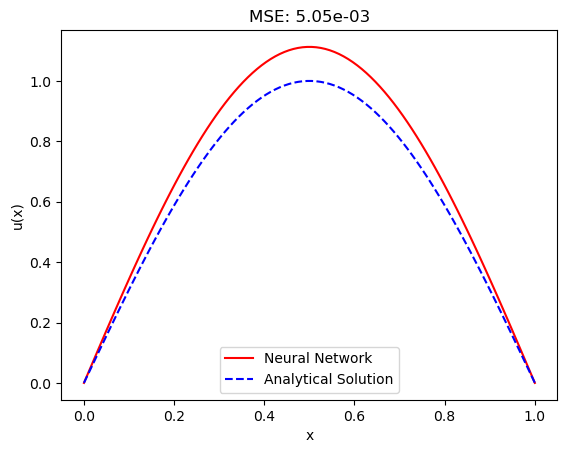

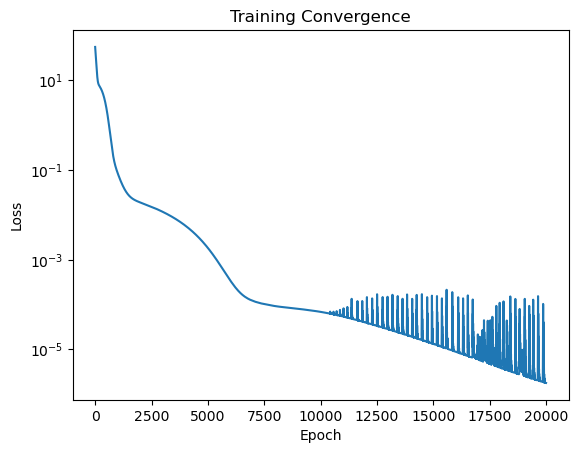

In [100]:
x_test = torch.linspace(0, 1, 100).view(-1,1)
u_pred = trialFunc(x_test, network(x_test)).detach().numpy()
u_exact = solution(x_test).detach().numpy()

plt.plot(x_test, u_pred, 'r-', label='Neural Network')
plt.plot(x_test, u_exact, 'b--', label='Analytical Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.title(f'MSE: {np.mean(u_pred - u_exact)**2:.2e}')
plt.show()

plt.semilogy(costList)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Convergence')
plt.show()